<a href="https://colab.research.google.com/github/SakshyamAryal077/Class-Balancing-Techniques-for-MIT-BIH-ARRYTHMIA-DETECTION./blob/main/adasyn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# If needed, install imbalanced-learn
!pip install imbalanced-learn


In [ ]:
import numpy as np
import torch
from imblearn.over_sampling import ADASYN
from google.colab import files
from sklearn.preprocessing import LabelEncoder




In [ ]:
# Load your saved subset files
X_train_small = np.load("X_trainsmall.npy")
y_train_small = np.load("y_trainsmall.npy")

print("Original X_train_small shape:", X_train_small.shape)
print("Original y_train_small shape:", y_train_small.shape)

classes, counts = np.unique(y_train_small, return_counts=True)
print("\nClass distribution before adasyn:")
for cls, cnt in zip(classes, counts):
    print(f"Class {cls}: {cnt}")


Original X_train_small shape: (27010, 360, 1)
Original y_train_small shape: (27010,)

Class distribution before smoteenn:
Class 0: 193
Class 1: 21680
Class 2: 2734
Class 3: 667
Class 4: 1736


In [ ]:
from imblearn.over_sampling import ADASYN
import numpy as np

print("Original X_train_small shape:", X_train_small.shape)
print("Original y_train_small shape:", y_train_small.shape)

classes_before, counts_before = np.unique(y_train_small, return_counts=True)
print("\nClass distribution before ADASYN:")
for cls, cnt in zip(classes_before, counts_before):
    print(f"Class {cls}: {cnt}")

# Flatten for ADASYN
X_train_flat = X_train_small.reshape(X_train_small.shape[0], -1)
print("\nFlattened X_train shape:", X_train_flat.shape)

# Use smaller n_neighbors if very small minority classes exist
adasyn = ADASYN(random_state=42, n_neighbors=3)

X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_flat, y_train_small)

print("\nAfter ADASYN X shape:", X_train_adasyn.shape)
print("After ADASYN y shape:", y_train_adasyn.shape)

# Reshape back to original ECG shape
X_train_adasyn = X_train_adasyn.reshape(X_train_adasyn.shape[0], *X_train_small.shape[1:])

print("Reshaped X_train_adasyn shape:", X_train_adasyn.shape)

classes_after, counts_after = np.unique(y_train_adasyn, return_counts=True)
print("\nClass distribution after ADASYN:")
for cls, cnt in zip(classes_after, counts_after):
    print(f"Class {cls}: {cnt}")


Original X_train_small shape: (27010, 360, 1)
Original y_train_small shape: (27010,)

Class distribution before ADASYN:
Class 0: 193
Class 1: 21680
Class 2: 2734
Class 3: 667
Class 4: 1736

Flattened X_train shape: (27010, 360)

After ADASYN X shape: (108387, 360)
After ADASYN y shape: (108387,)
Reshaped X_train_adasyn shape: (108387, 360, 1)

Class distribution after ADASYN:
Class 0: 21665
Class 1: 21680
Class 2: 21701
Class 3: 21684
Class 4: 21657


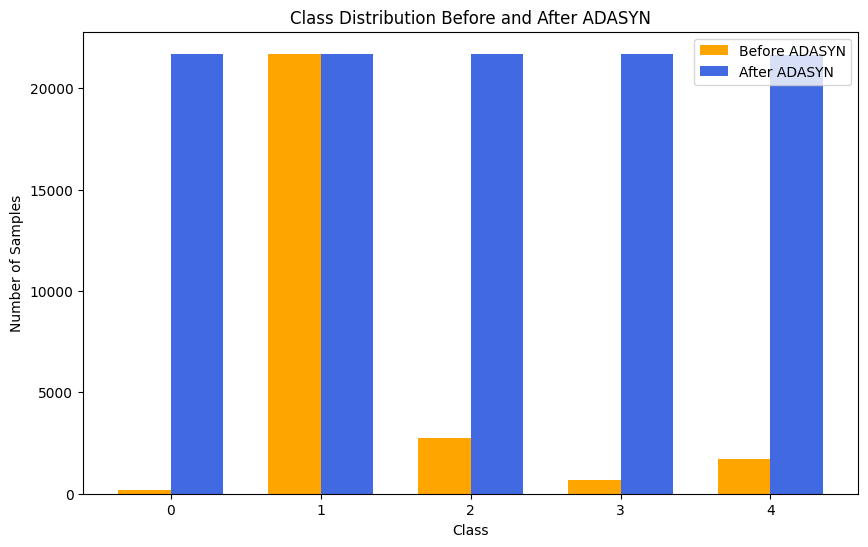

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))

x = np.arange(len(classes_before))
width = 0.35

plt.bar(x - width/2, counts_before, width, label='Before ADASYN', color='orange')
plt.bar(x + width/2, counts_after, width, label='After ADASYN', color='royalblue')

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Before and After ADASYN")
plt.xticks(x, classes_before)
plt.legend()
plt.show()


In [ ]:
# Save balanced data
np.save("X_train_adasyn.npy", X_train_adasyn)
np.save("y_train_adasyn.npy", y_train_adasyn)

